6      132.9774
7     1374.8160
8    13838.9200
Name: mean, dtype: float64
6      146.1962
7     1528.0620
8    15473.4600
Name: mean, dtype: float64


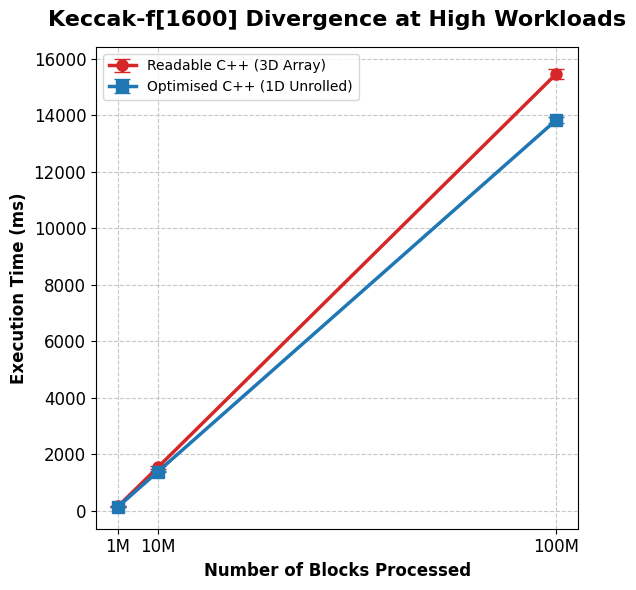

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Safely check if both files exist
file_readable = 'readable_results.csv'
file_optimized = 'optimized_results.csv'

if not os.path.exists(file_readable) or not os.path.exists(file_optimized):
    raise FileNotFoundError("Missing CSV files! Please make sure you have run BOTH C++ scripts first.")

# 2. Load the raw data
df_readable = pd.read_csv(file_readable)
df_optimized = pd.read_csv(file_optimized)

# 3. Calculate Mean and Standard Deviation
readable_stats = df_readable.groupby('Blocks')['Time_ms'].agg(['mean', 'std']).reset_index()
optimized_stats = df_optimized.groupby('Blocks')['Time_ms'].agg(['mean', 'std']).reset_index()

# --- THE FIX: Filter the data to ONLY zoom in on the massive workloads ---
# We isolate blocks >= 1,000,000 to clearly see the divergence
readable_stats = readable_stats[readable_stats['Blocks'] >= 1000000]
optimized_stats = optimized_stats[optimized_stats['Blocks'] >= 1000000]

# 4. Build the Plot
plt.figure(figsize=(6, 6))

print(optimized_stats['mean'])  
print(readable_stats['mean'])
# Plot Readable Data 
plt.errorbar(readable_stats['Blocks'], readable_stats['mean'], yerr=readable_stats['std'], 
             fmt='-o', capsize=6, label='Readable C++ (3D Array)', color='#d62728', linewidth=2.5, markersize=8)

# Plot Optimized Data 
plt.errorbar(optimized_stats['Blocks'], optimized_stats['mean'], yerr=optimized_stats['std'], 
             fmt='-s', capsize=6, label='Optimised C++ (1D Unrolled)', color='#1f77b4', linewidth=2.5, markersize=8)

# 5. Presentation-ready Formatting
plt.title('Keccak-f[1600] Divergence at High Workloads', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Blocks Processed', fontsize=12, fontweight='bold')
plt.ylabel('Execution Time (ms)', fontsize=12, fontweight='bold')

# Custom X-axis labels to make it look clean (e.g., "100M" instead of "100000000")
x_labels = [f"{int(x/1000000)}M" for x in readable_stats['Blocks']]
plt.xticks(readable_stats['Blocks'], x_labels, fontsize=12)
plt.yticks(fontsize=12)

# Grid and Legend
plt.grid(True, which="major", linestyle='--', alpha=0.7)
plt.legend(fontsize=10, loc='upper left')

# Render
plt.tight_layout()
plt.show()